# TP2 — Agrégation et clustering

**UE Données complexes — M1 SDSC**  
Données de qualité d'eau 2013, bassin Rhin-Meuse (NAIADES)

**Objectif** : agréger les données à l'échelle annuelle (par station), choisir le nombre de clusters et caractériser les groupes obtenus.

## 1. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

PARAM_SHORT = [
    'Température', 'pH', 'O2_dissous', 'Conductivité', 'MES', 'Turbidité',
    'Carbone_org', 'Nitrates', 'Phosphore_total', 'Azote_Kjeldahl',
    'Orthophosphates', 'Ammonium', 'Nitrites', 'DBO5', 'DCO'
]

In [2]:
df_clean = pd.read_csv(
    '../outputs/tables/tp1_clean_dataset.csv',
    parse_dates=['DatePrel'],
    dtype={'CdStationMesureEauxSurface': str}
)
print(f'Jeu de données chargé : {df_clean.shape}')
print(f'Stations : {df_clean["CdStationMesureEauxSurface"].nunique()}')
df_clean.head(3)

Jeu de données chargé : (3223, 18)
Stations : 274


,CdStationMesureEauxSurface,LbStationMesureEauxSurface,DatePrel,Température,pH,O2_dissous,Conductivité,MES,Turbidité,Carbone_org,Nitrates,Phosphore_total,Azote_Kjeldahl,Orthophosphates,Ammonium,Nitrites,DBO5,DCO
0,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-01-07,7.0,8.2,12.4,384.0,3.6,3.00,1.9,7.4,0.02,0.6,0.06,0.07,0.03,3.4,6.0
1,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-02-04,5.9,8.1,12.7,378.0,22.0,15.00,2.2,7.4,0.04,0.5,0.09,0.08,0.03,2.1,8.0
2,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-03-04,5.4,8.3,14.6,420.0,2.4,0.99,1.3,7.8,0.02,0.5,0.04,0.08,0.04,1.8,5.0


## 2. Agrégation annuelle par moyenne

Pour chaque station on calcule la **moyenne annuelle** de chacun des 15 paramètres sur l'ensemble des prélèvements de 2013. Cette agrégation résume le profil moyen de qualité d'eau sur l'année.

In [3]:
# Agrégation : moyenne par station (sur tous les prélèvements de 2013)
cols_param = [p for p in PARAM_SHORT if p in df_clean.columns]

df_agg = (
    df_clean.groupby('CdStationMesureEauxSurface')[cols_param]
    .mean()
)

print(f'Tableau agrégé : {df_agg.shape}  (stations × paramètres)')
print(f'Valeurs manquantes par paramètre :')
print(df_agg.isna().sum().to_string())

Tableau agrégé : (274, 15)  (stations × paramètres)
Valeurs manquantes par paramètre :
Température         0
pH                  0
O2_dissous          0
Conductivité        0
MES                 0
Turbidité          46
Carbone_org         0
Nitrates           46
Phosphore_total     0
Azote_Kjeldahl      0
Orthophosphates    46
Ammonium           46
Nitrites           46
DBO5                0
DCO                 0


In [4]:
# On ne conserve que les stations sans aucune valeur manquante après agrégation
df_agg_clean = df_agg.dropna()
print(f'Stations avec tous les paramètres renseignés : {len(df_agg_clean)}')
print(f'Stations éliminées (paramètre encore manquant) : {len(df_agg) - len(df_agg_clean)}')
df_agg_clean.describe().round(3)

Stations avec tous les paramètres renseignés : 228
Stations éliminées (paramètre encore manquant) : 46


,Température,pH,O2_dissous,Conductivité,MES,Turbidité,Carbone_org,Nitrates,Phosphore_total,Azote_Kjeldahl,Orthophosphates,Ammonium,Nitrites,DBO5,DCO
count,228.000,228.000,228.000,228.000,228.000,228.000,228.000,228.000,228.000,228.000,228.000,228.000,228.000,228.000,228.000
mean,10.934,7.873,9.942,553.065,16.367,7.953,3.454,10.700,0.103,0.707,0.215,0.168,0.090,1.586,11.949
std,1.542,0.299,0.948,485.353,14.147,6.052,1.321,7.500,0.102,0.442,0.236,0.381,0.122,0.606,5.103
min,7.150,6.777,6.136,28.667,2.000,0.343,0.900,1.233,0.011,0.500,0.016,0.050,0.010,0.850,5.000
25%,9.957,7.728,9.399,211.517,7.804,3.462,2.561,4.925,0.048,0.517,0.093,0.061,0.032,1.267,8.750
50%,10.938,7.944,9.983,450.716,13.218,6.424,3.338,9.479,0.081,0.589,0.160,0.082,0.064,1.458,10.917
75%,11.725,8.072,10.567,697.438,20.223,10.438,4.056,13.977,0.125,0.733,0.273,0.123,0.101,1.685,14.000
max,16.455,8.429,11.792,3298.769,136.300,34.925,8.500,46.850,1.022,4.058,2.634,3.498,1.143,5.817,40.750


## 3. Choix du nombre de clusters

On normalise les données (StandardScaler) avant le clustering car les paramètres ont des unités très différentes. On évalue ensuite le nombre de clusters k avec :
1. La **méthode du coude** (inertie intra-classe)
2. Le **score de silhouette** moyen

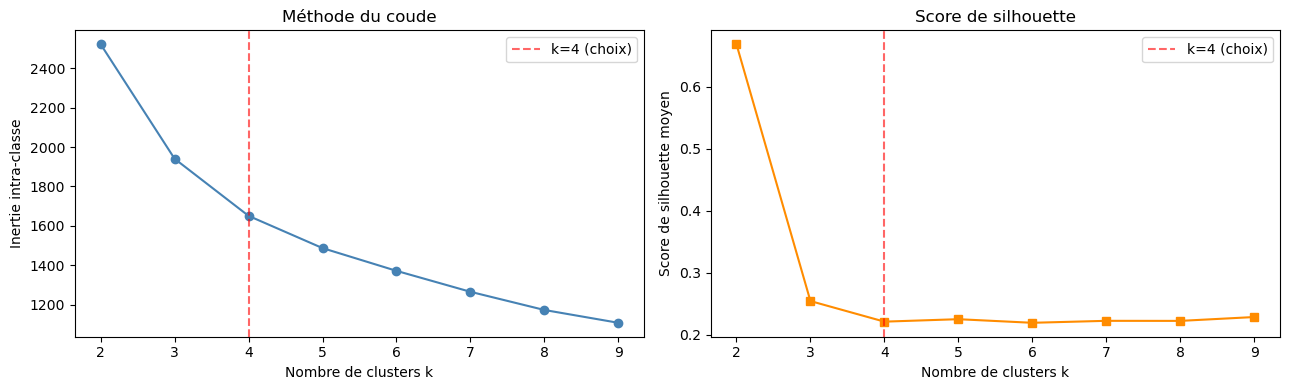

k=2  silhouette=0.6682
k=3  silhouette=0.2545
k=4  silhouette=0.2213
k=5  silhouette=0.2253
k=6  silhouette=0.2195
k=7  silhouette=0.2227
k=8  silhouette=0.2225
k=9  silhouette=0.2288


In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(df_agg_clean)

K_range = range(2, 10)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie intra-classe')
axes[0].set_title('Méthode du coude')
axes[0].axvline(4, color='red', linestyle='--', alpha=0.6, label='k=4 (choix)')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, 's-', color='darkorange')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score de silhouette moyen')
axes[1].set_title('Score de silhouette')
axes[1].axvline(4, color='red', linestyle='--', alpha=0.6, label='k=4 (choix)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/tp2_choix_k.png', dpi=120)
plt.show()

for k, s in zip(K_range, silhouettes):
    print(f'k={k}  silhouette={s:.4f}')

### Analyse de silhouette pour le k retenu

Le score de silhouette est maximal à **k = 2** (≈ 0.67), mais cette bipartition ne fait que séparer les stations de montagne (faible conductivité) du reste — peu informatif. À partir de k = 3, le score se stabilise autour de 0.22–0.23 et la méthode du coude montre un gain d'inertie significatif jusqu'à **k = 4** puis une décroissance plus lente. On retient **k = 4 clusters**, qui offre une granularité pertinente (eaux naturelles de montagne / agricoles / industrielles / très polluées) tout en restant interprétable.

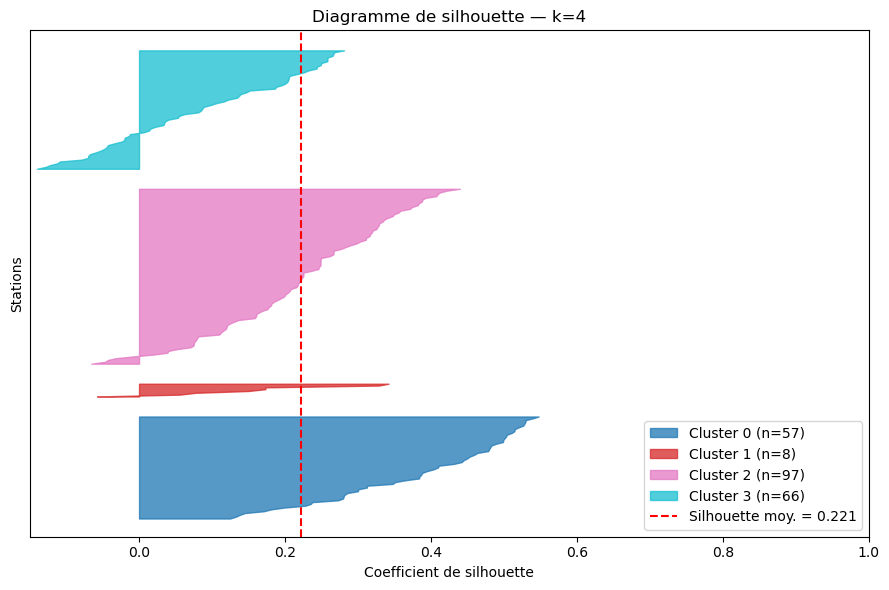

Score de silhouette moyen : 0.2213
Distribution : {0: 57, 1: 8, 2: 97, 3: 66}


In [6]:
N_CLUSTERS = 4
RANDOM_STATE = 42

km_final = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=30)
labels = km_final.fit_predict(X)

# Diagramme de silhouette
sample_sil = silhouette_samples(X, labels)
avg_sil = silhouette_score(X, labels)

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim([-0.15, 1])
ax.set_ylim([0, len(X) + (N_CLUSTERS + 1) * 10])
y_lower = 10
colors = cm.tab10(np.linspace(0, 1, N_CLUSTERS))
for i in range(N_CLUSTERS):
    vals = np.sort(sample_sil[labels == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.75,
                      label=f'Cluster {i} (n={len(vals)})')
    y_lower = y_upper + 10
ax.axvline(avg_sil, color='red', linestyle='--', label=f'Silhouette moy. = {avg_sil:.3f}')
ax.set_title(f'Diagramme de silhouette — k={N_CLUSTERS}')
ax.set_xlabel('Coefficient de silhouette')
ax.set_ylabel('Stations')
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/tp2_silhouette.png', dpi=120)
plt.show()
print(f'Score de silhouette moyen : {avg_sil:.4f}')
print(f'Distribution : {pd.Series(labels).value_counts().sort_index().to_dict()}')

## 4. Caractérisation des clusters

On examine les valeurs moyennes de chaque paramètre par cluster pour interpréter les profils de qualité.

In [7]:
df_agg_labeled = df_agg_clean.copy()
df_agg_labeled['cluster'] = labels

cluster_means = df_agg_labeled.groupby('cluster')[cols_param].mean().round(3)
print('Valeurs moyennes par cluster :')
cluster_means

Valeurs moyennes par cluster :


,Température,pH,O2_dissous,Conductivité,MES,Turbidité,Carbone_org,Nitrates,Phosphore_total,Azote_Kjeldahl,Orthophosphates,Ammonium,Nitrites,DBO5,DCO
cluster,,,,,,,,,,,,,,,
0,9.328,7.477,10.728,119.344,8.086,3.337,2.757,3.798,0.046,0.533,0.089,0.071,0.024,1.329,9.765
1,11.450,7.942,7.772,1079.012,34.090,10.212,4.569,20.460,0.472,2.601,1.009,1.777,0.604,3.787,24.119
2,11.567,8.022,9.996,508.906,12.721,5.930,2.958,12.390,0.078,0.579,0.168,0.096,0.069,1.428,9.485
3,11.329,7.987,9.446,928.793,26.728,14.639,4.650,12.993,0.143,0.817,0.298,0.161,0.114,1.773,15.981


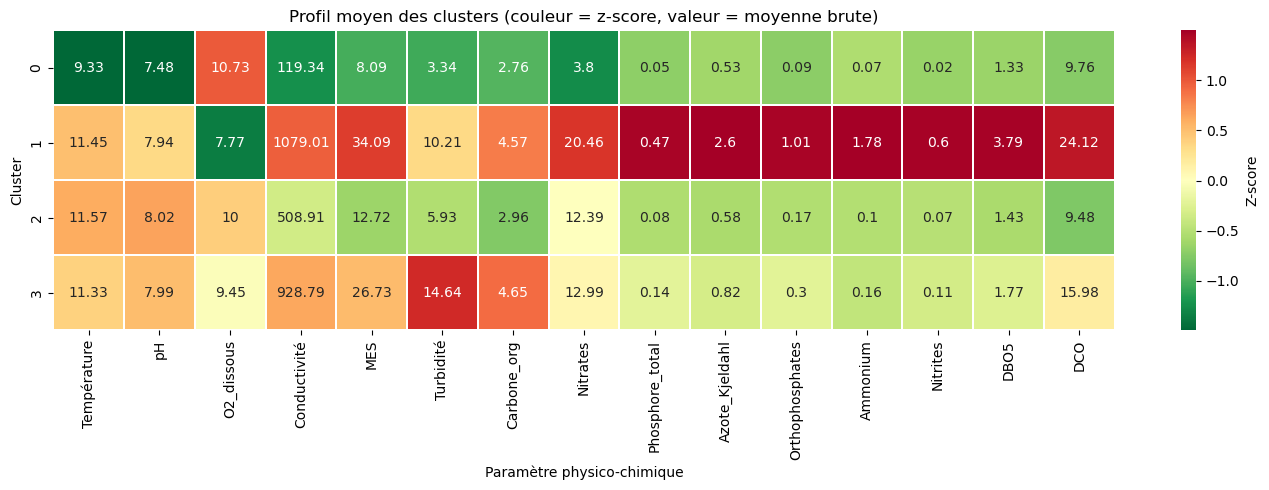

In [8]:
# Heatmap normalisée (z-score) des moyennes par cluster
cluster_means_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    cluster_means_z,
    annot=cluster_means.round(2),
    fmt='g',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Z-score'}
)
ax.set_title('Profil moyen des clusters (couleur = z-score, valeur = moyenne brute)', fontsize=12)
ax.set_xlabel('Paramètre physico-chimique')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('../outputs/figures/tp2_heatmap_clusters.png', dpi=120)
plt.show()

/tmp/ipykernel_91228/896059526.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=[f'C{i}' for i in range(N_CLUSTERS)])
/tmp/ipykernel_91228/896059526.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=[f'C{i}' for i in range(N_CLUSTERS)])
/tmp/ipykernel_91228/896059526.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=[f'C{i}' for i in range(N_CLUSTERS)])
/tmp/ipykernel_91228/896059526.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been re

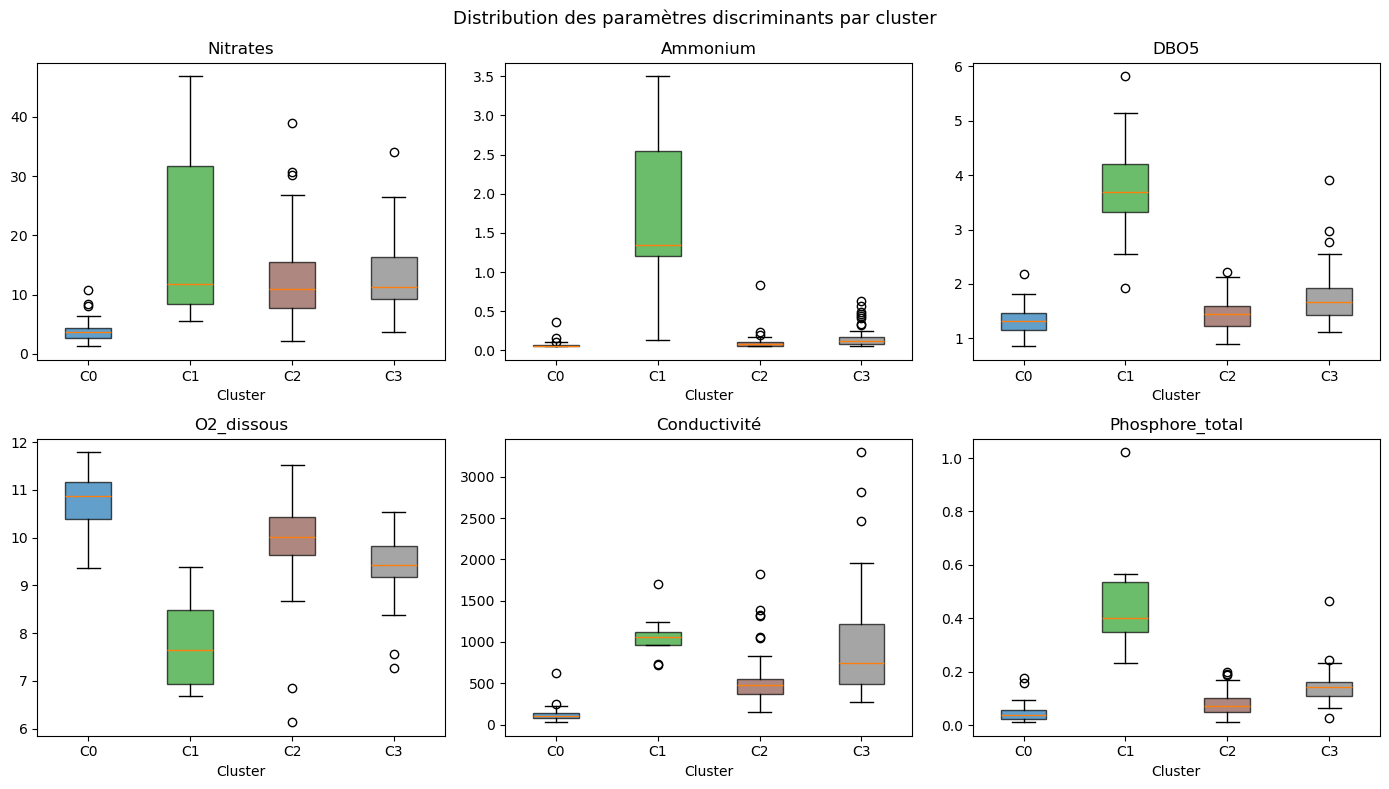

In [9]:
# Boxplots de quelques paramètres discriminants par cluster
discriminants = ['Nitrates', 'Ammonium', 'DBO5', 'O2_dissous', 'Conductivité', 'Phosphore_total']
labels_names = {0: 'C0', 1: 'C1', 2: 'C2', 3: 'C3'}
df_plot = df_agg_labeled.copy()
df_plot['cluster_label'] = df_plot['cluster'].map(labels_names)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors_c = [cm.tab10(i / N_CLUSTERS) for i in range(N_CLUSTERS)]

for ax, param in zip(axes, discriminants):
    data = [df_plot.loc[df_plot['cluster'] == c, param].dropna().values for c in range(N_CLUSTERS)]
    bp = ax.boxplot(data, patch_artist=True, labels=[f'C{i}' for i in range(N_CLUSTERS)])
    for patch, color in zip(bp['boxes'], colors_c):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(param)
    ax.set_xlabel('Cluster')

plt.suptitle('Distribution des paramètres discriminants par cluster', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/tp2_boxplots_clusters.png', dpi=120)
plt.show()

In [10]:
# Résumé textuel des clusters
print('=== Résumé des clusters ===')
n_cluster = df_agg_labeled['cluster'].value_counts().sort_index()
for c in range(N_CLUSTERS):
    row = cluster_means.loc[c]
    print(f'\nCluster {c} ({n_cluster[c]} stations) :')
    print(f'  NO3={row["Nitrates"]:.1f}  NH4={row["Ammonium"]:.3f}  DBO5={row["DBO5"]:.1f}'
          f'  DCO={row["DCO"]:.1f}  O2={row["O2_dissous"]:.1f}  Cond={row["Conductivité"]:.0f}')

=== Résumé des clusters ===

Cluster 0 (57 stations) :
  NO3=3.8  NH4=0.071  DBO5=1.3  DCO=9.8  O2=10.7  Cond=119

Cluster 1 (8 stations) :
  NO3=20.5  NH4=1.777  DBO5=3.8  DCO=24.1  O2=7.8  Cond=1079

Cluster 2 (97 stations) :
  NO3=12.4  NH4=0.096  DBO5=1.4  DCO=9.5  O2=10.0  Cond=509

Cluster 3 (66 stations) :
  NO3=13.0  NH4=0.161  DBO5=1.8  DCO=16.0  O2=9.4  Cond=929


## 5. Export

In [11]:
# Export des labels de cluster par station
df_station_clusters = df_agg_labeled[['cluster']].reset_index()
df_station_clusters.columns = ['CdStationMesureEauxSurface', 'cluster']

# On exporte aussi les moyennes par paramètre par station (utile pour TP3)
df_agg_export = df_agg_labeled.reset_index()

df_station_clusters.to_csv('../outputs/tables/tp2_station_clusters.csv', index=False)
df_agg_export.to_csv('../outputs/tables/tp2_station_means.csv', index=False)
cluster_means.to_csv('../outputs/tables/tp2_cluster_means.csv')

print(f'Export OK : {len(df_station_clusters)} stations → ../outputs/tables/tp2_station_clusters.csv')
df_station_clusters.head()

Export OK : 228 stations → ../outputs/tables/tp2_station_clusters.csv


,CdStationMesureEauxSurface,cluster
0,02000010,2
1,02000011,2
2,02001000,3
3,02001025,3
4,02001050,2
